In [ ]:
#this is the 8th time training of mobilenetv2 which applies TRANSFER LEARNING
#21 March 2026 Saturday
# this improvement is made based on the version 7 that achieve good val accuracy after fien tuning 0.91512
# Few changes to the parameters are done
# label smoothing is added, unfreeze the last 30 layers, reduce augmentation augmentation
#import the model and necessary packagaes, preprocessing utlities
#code below is refered from keras documentation
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt # plotting training curves
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


In [ ]:
#mount the google drive in colab so that no reupload needed every time colab session ends
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
#listing out the directory structure and find the zip file for dog skin disease
os.listdir('/content/drive/MyDrive')

#find the zzip file in the folder that named as fyp_version8_datatsets folder
os.listdir('/content/drive/MyDrive/fyp_version8_datasets')


['dog_skin_diseases_datasets.zip']

In [ ]:
#extraction of the zip file
import zipfile

zip_path ='/content/drive/MyDrive/fyp_version8_datasets/dog_skin_diseases_datasets.zip'
extract_path = '/content/drive/MyDrive/fyp_version8_datasets/dog_skin_diseases_datasets'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  members = zip_ref.infolist()
  total = len(members)
  for i, member in enumerate(members):
    zip_ref.extract(member,extract_path)
    if i % 100 == 0:
      print(f"Progress: {i}/{total} files ({(i/total)*100:.1f}%)")

print("Extraction completed ")

Progress: 0/4338 files (0.0%)
Progress: 100/4338 files (2.3%)
Progress: 200/4338 files (4.6%)
Progress: 300/4338 files (6.9%)
Progress: 400/4338 files (9.2%)
Progress: 500/4338 files (11.5%)
Progress: 600/4338 files (13.8%)
Progress: 700/4338 files (16.1%)
Progress: 800/4338 files (18.4%)
Progress: 900/4338 files (20.7%)
Progress: 1000/4338 files (23.1%)
Progress: 1100/4338 files (25.4%)
Progress: 1200/4338 files (27.7%)
Progress: 1300/4338 files (30.0%)
Progress: 1400/4338 files (32.3%)
Progress: 1500/4338 files (34.6%)
Progress: 1600/4338 files (36.9%)
Progress: 1700/4338 files (39.2%)
Progress: 1800/4338 files (41.5%)
Progress: 1900/4338 files (43.8%)
Progress: 2000/4338 files (46.1%)
Progress: 2100/4338 files (48.4%)
Progress: 2200/4338 files (50.7%)
Progress: 2300/4338 files (53.0%)
Progress: 2400/4338 files (55.3%)
Progress: 2500/4338 files (57.6%)
Progress: 2600/4338 files (59.9%)
Progress: 2700/4338 files (62.2%)
Progress: 2800/4338 files (64.5%)
Progress: 2900/4338 files (66.9

In [ ]:
#define the train, test and valid folder

train_directory= '/content/drive/MyDrive/fyp_version8_datasets/dog_skin_diseases_datasets/train'
valid_directory = '/content/drive/MyDrive/fyp_version8_datasets/dog_skin_diseases_datasets/valid'
test_directory = '/content/drive/MyDrive/fyp_version8_datasets/dog_skin_diseases_datasets/test'

#check for the folder and verify all 6 classes exists
for split, path in [('train', train_directory),('valid',valid_directory),('test',test_directory)]:
  classes = os.listdir(path)
  print(f"{split}:{len(classes)} classes --> {classes}")


train:6 classes --> ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']
valid:6 classes --> ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']
test:6 classes --> ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']


In [ ]:
#preprocess the image
#applying data augmentation technique
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
      preprocessing_function=preprocess_input, #to expects pixel calue in the range [-1,1]
      rotation_range=20,
      width_shift_range=0.08,
      height_shift_range=0.08,
      shear_range=0.08,
      zoom_range=0.15,
      horizontal_flip=True,
      vertical_flip=True,
      brightness_range=[0.85,1.15],
      fill_mode='nearest'
)

#for validation folder and test dataset, only preprocess it no augmentation
valid_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

#load image from the folder
train_generator = train_datagen.flow_from_directory(train_directory,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='categorical')
valid_generator = valid_test_datagen.flow_from_directory(valid_directory,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='categorical')
test_generator = valid_test_datagen.flow_from_directory(test_directory,target_size=IMAGE_SIZE,batch_size=BATCH_SIZE,class_mode='categorical', shuffle=False) #shuffle is set to false to keep order for evaluation

#verify images in the folder
print("Classes found:", train_generator.class_indices)
print("Train images:", train_generator.samples)
print("Valid images:", valid_generator.samples)
print("Test images:", test_generator.samples)

Found 3022 images belonging to 6 classes.
Found 860 images belonging to 6 classes.
Found 433 images belonging to 6 classes.
Classes found: {'Dermatitis': 0, 'Fungal_infections': 1, 'Healthy': 2, 'Hypersensitivity': 3, 'demodicosis': 4, 'ringworm': 5}
Train images: 3022
Valid images: 860
Test images: 433


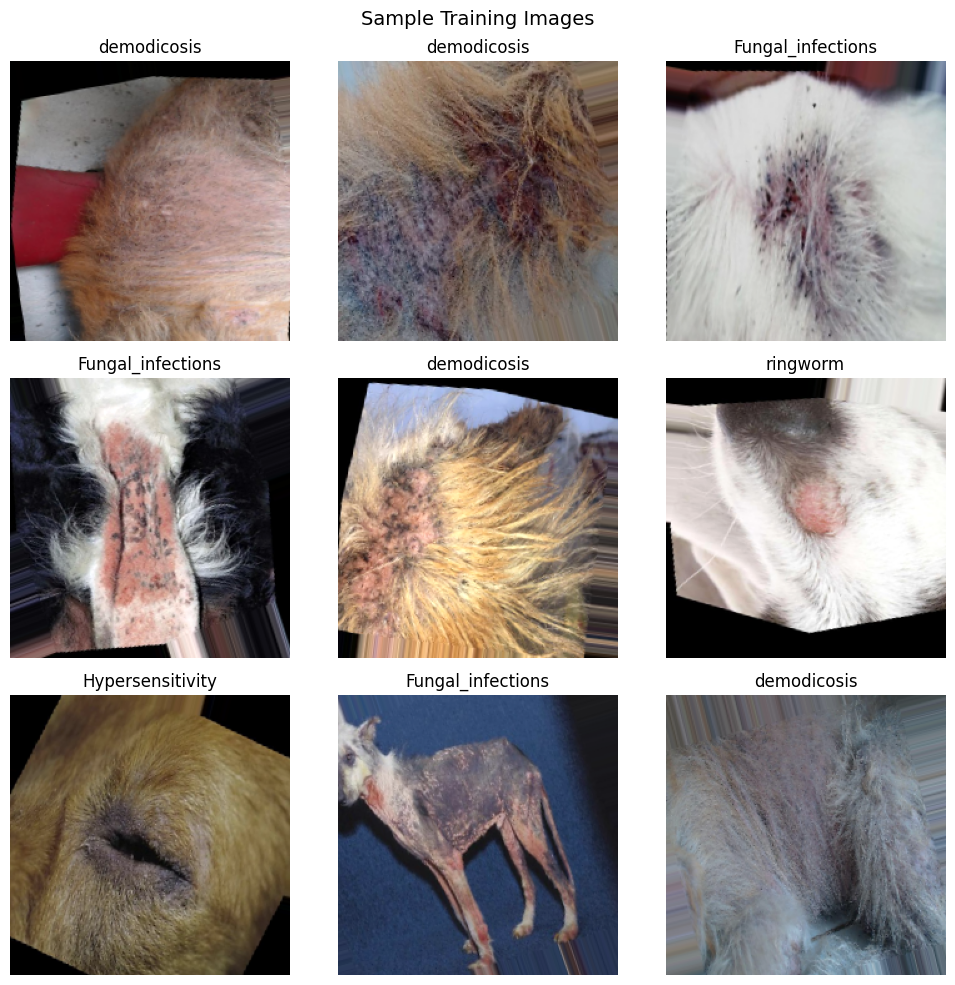

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#get class names from generator
class_names = list(train_generator.class_indices.keys())

#get one batch of images and lables
images, labels = next(iter(train_generator))

plt.figure(figsize=(10,10))
for i in range(9):
  ax=plt.subplot(3, 3, i+1)
  #reverse the preprocessing back to [0,1] for display
  img=images[i] / 2+0.5
  img=np.clip(img,0,1)
  plt.imshow(img)
  plt.title(class_names[np.argmax(labels[i])])
  plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import BatchNormalization
#build the model
baseModel = MobileNetV2(
    input_shape=(224,224,3),
    weights='imagenet',
    include_top = False,
)

#freeze the base model during inital training
baseModel.trainable = False

x= baseModel.output
x = GlobalAveragePooling2D()(x)
x= Dense(256,activation='relu')(x)
x= BatchNormalization()(x) #added batchnormalization to stablizes training
x= Dropout(0.5)(x)
output = Dense(6,activation='softmax')(x)

model = Model(inputs=baseModel.input,outputs=output)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,486 (9.87 MB)

 Trainable params: 329,990 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
#compute the class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy  as np

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.9224664224664225), 1: np.float64(1.3431111111111111), 2: np.float64(1.0237127371273713), 3: np.float64(2.189855072463768), 4: np.float64(0.8565759637188208), 5: np.float64(0.6367467340918669)}


In [ ]:
#compile the model
#initial training (all layers are freeze)
import tensorflow as tf

model.compile(optimizer=Adam(learning_rate=0.001),loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),metrics=['accuracy',
                                                                                                                                  tf.keras.metrics.Precision(name='precision'),
                                                                                                                                  tf.keras.metrics.Recall(name='recall'),
                                                                                                                                  tf.keras.metrics.AUC(name='auc'),
                                                                                                                                  tf.keras.metrics.F1Score(name='f1_score',average='macro')
                                                                                                                                  ])

early_stop = EarlyStopping(monitor='val_accuracy', patience=5,restore_best_weights=True, verbose=1)

history = model.fit(
    train_generator,
    validation_data = valid_generator,
    epochs = 15, #increase the num of epochs
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 117s 988ms/step - accuracy: 0.6135 - auc: 0.8741 - f1_score: 0.5817 - loss: 1.5238 - precision: 0.6712 - recall: 0.5397 - val_accuracy: 0.7837 - val_auc: 0.9619 - val_f1_score: 0.7200 - val_loss: 0.9490 - val_precision: 0.8511 - val_recall: 0.7244
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 65s 681ms/step - accuracy: 0.7280 - auc: 0.9382 - f1_score: 0.6974 - loss: 1.1161 - precision: 0.7976 - recall: 0.6612 - val_accuracy: 0.8105 - val_auc: 0.9682 - val_f1_score: 0.7690 - val_loss: 0.9254 - val_precision: 0.8648 - val_recall: 0.7733
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 65s 680ms/step - accuracy: 0.7584 - auc: 0.9527 - f1_score: 0.7306 - loss: 1.0040 - precision: 0.8335 - recall: 0.6807 - val_accuracy: 0.8465 - val_auc: 0.9751 - val_f1_score: 0.8208 - val_loss: 0.8372 - val_precision: 0.8848 - val_recall: 0.7860
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 63s 668ms/step - accuracy: 0.7942 - auc: 0.9637 - f1_score: 0.7732 - loss: 0.9229 - precision: 0.8600 - re

In [ ]:
#fine tuning  (unfreeze the last 30 )
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#unfreeze the base model
baseModel.trainable = True

#unfreeze the last 30 layers
fine_tune_at = len(baseModel.layers)-30
for layer in baseModel.layers[:fine_tune_at]:
  layer.trainable = False

#freeze BatchNormalization layers
for layer in baseModel.layers:
  if isinstance (layer, tf.keras.layers.BatchNormalization):
    layer.trainable = False #stablizes fine tuning

#verify
print("Total layers:", len(baseModel.layers))
print("Trainable layers:", sum([1 for layer in baseModel.layers if layer.trainable]))

total_steps = 30 * (train_generator.samples // BATCH_SIZE)

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=total_steps,
    alpha=1e-6
)

#recompile with lower learning rate
model.compile(
    optimizer = Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
              tf.keras.metrics.Recall(name='recall'),
              tf.keras.metrics.AUC(name='auc'),
              tf.keras.metrics.F1Score(name='f1_score',average='macro')
    ]
)


checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/fyp_version8_datasets/best_model_V8.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
    )

#add callbacks for fine tuning
early_stop_ft = EarlyStopping(
    monitor='val_loss', #use val_loss to monitor as it iss more sensitive to overfit
    patience=7,
    restore_best_weights=True,
    verbose=1
    )



#history of fine tune
history_fine_tune = model.fit(
    train_generator,
    validation_data = valid_generator,
    epochs = 30,
    class_weight = class_weight_dict,
    callbacks=[early_stop_ft, checkpoint]
)

print("Fine tune completed")


Total layers: 154
Trainable layers: 19
Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.7821 - auc: 0.9637 - f1_score: 0.7551 - loss: 0.9235 - precision: 0.8525 - recall: 0.6862
Epoch 1: val_accuracy improved from None to 0.81744, saving model to /content/drive/MyDrive/fyp_version8_datasets/best_model_V8.keras

Epoch 1: finished saving model to /content/drive/MyDrive/fyp_version8_datasets/best_model_V8.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 97s 868ms/step - accuracy: 0.7919 - auc: 0.9673 - f1_score: 0.7656 - loss: 0.9025 - precision: 0.8664 - recall: 0.7042 - val_accuracy: 0.8174 - val_auc: 0.9714 - val_f1_score: 0.7788 - val_loss: 0.9120 - val_precision: 0.8614 - val_recall: 0.7802
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.8587 - auc: 0.9804 - f1_score: 0.8384 - loss: 0.7919 - precision: 0.9122 - recall: 0.7935
Epoch 2: val_accuracy improved from 0.81744 to 0.85233, saving model to /content/drive/MyDrive/fyp_version8_datasets/best_model_V8.keras

Epo

In [ ]:
#evaluate on test set
test_loss, test_accuracy, test_precision, test_recall, test_auc, test_f1 = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"\nTest Recall: {test_recall:.4f}")
print(f"\nTest Auc: {test_auc:.4f}")
print(f"\nTest F1 Score: {test_f1:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9630 - auc: 0.9919 - f1_score: 0.9615 - loss: 0.5864 - precision: 0.9649 - recall: 0.9515

Test Accuracy: 0.9630

Test Precision: 0.9649

Test Recall: 0.9515

Test Auc: 0.9919

Test F1 Score: 0.9615


In [ ]:
# Best val_accuracy achieved during fine-tuning
best_val_acc = max(history_fine_tune.history['val_accuracy'])
print("Best val_accuracy:", best_val_acc)

Best val_accuracy: 0.9581395387649536


In [ ]:
#classification report with f1 per class
from sklearn.metrics import classification_report
import numpy as np
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/fyp_version8_datasets/best_model_V8.keras')

#reset generator to ensure correct order
test_generator.reset() #so that by resetiing, predictions is aligned with true labels

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\n-- Pe class classification report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))


14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 578ms/step

-- Pe class classification report:
                   precision    recall  f1-score   support

       Dermatitis       0.98      0.94      0.96        66
Fungal_infections       0.91      0.94      0.93        54
          Healthy       0.96      0.94      0.95        69
 Hypersensitivity       1.00      0.97      0.98        29
      demodicosis       0.95      1.00      0.98       100
         ringworm       0.98      0.97      0.97       115

         accuracy                           0.96       433
        macro avg       0.96      0.96      0.96       433
     weighted avg       0.96      0.96      0.96       433



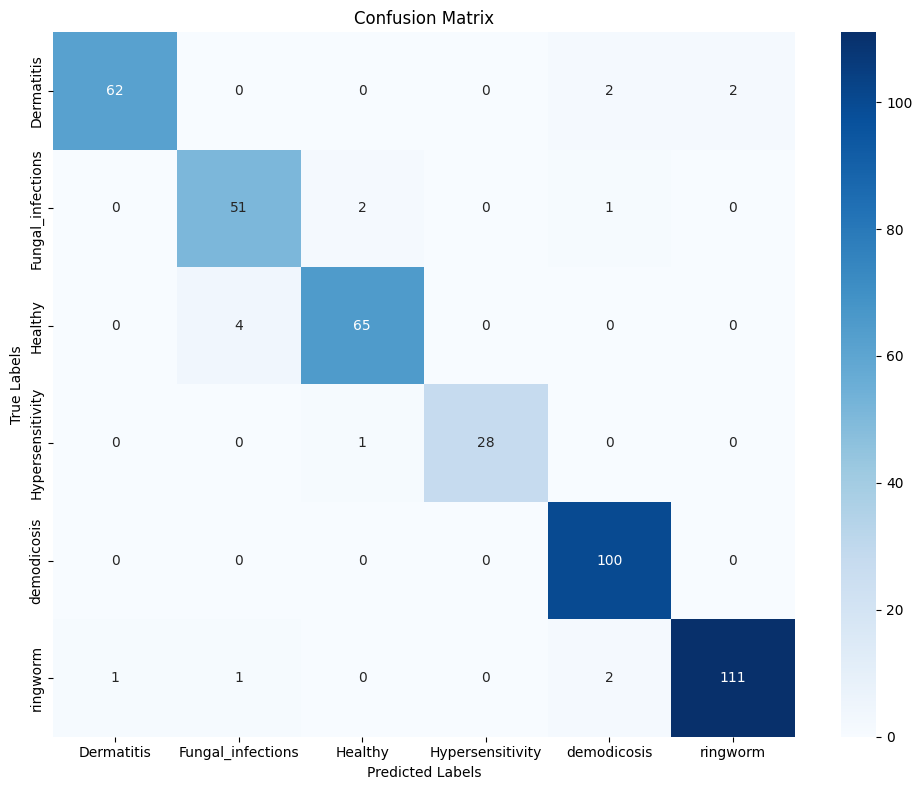

In [ ]:
#confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#test_generator been reset
test_generator.reset()

cm = confusion_matrix(y_true, y_pred_classes)
#plotting
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True, fmt='d',
            xticklabels = class_names,
            yticklabels = class_names,
            cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fyp_version8_datasets/confusion_matrix.png')
plt.show()

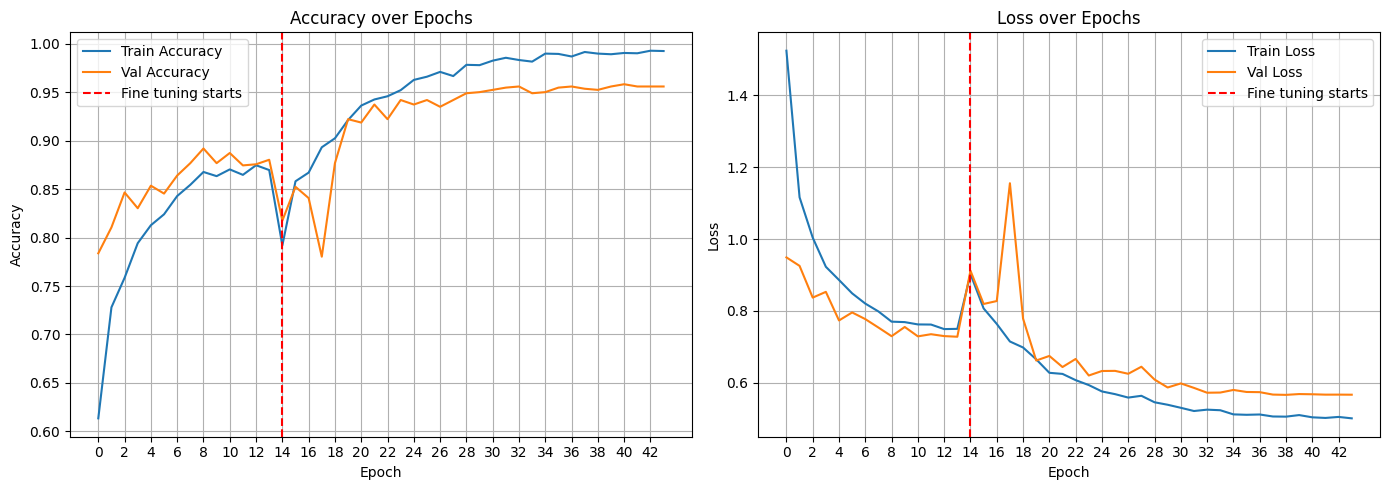

Training history plot saved!


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine Phase 1 and Phase 2 history
acc = history.history['accuracy'] + history_fine_tune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
loss = history.history['loss'] + history_fine_tune.history['loss']
val_loss = history.history['val_loss'] + history_fine_tune.history['val_loss']

# dynamic fine-tuning start point based on actual epochs run
actual_initial_epochs = len(history.history['accuracy'])



# Accuracy plot
axes[0].plot(acc, label='Train Accuracy')
axes[0].plot(val_acc, label='Val Accuracy')
axes[0].axvline(x=actual_initial_epochs, color='red', linestyle='--', label='Fine tuning starts')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(range(0,len(acc),2)) #marks the epoch num clearly
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(loss, label='Train Loss')
axes[1].plot(val_loss, label='Val Loss')
axes[1].axvline(x=actual_initial_epochs, color='red', linestyle='--', label='Fine tuning starts')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(range(0,len(acc),2))
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fyp_version8_datasets/training_history.png')
plt.show()
print("Training history plot saved!")